# 🎯 Modelo binario de zona — Multi-semilla + Curva ROC real

Reentrena el **modelo binario de zona** con varias semillas, reporta el **AUC media ± desviación** y genera automáticamente la **curva ROC promedio real** (`roc_zona_real.png`) para el documento del congreso.

**Tarea binaria:** zona segura (BI-RADS 0–3) = 0 · zona de riesgo (4–6) = 1. Test fijo (semilla 42).

⚠️ **Tiempo:** 3 entrenamientos (~45 min–1,5 h en MPS). Baja `SEEDS` a `[42,123]` si necesitas menos.

**Uso:** colócalo en `notebooks/`. Lee `../data/processed/dataset_clean.csv`. Restart + Run All.

## 1 · Configuración

In [1]:
import numpy as np, pandas as pd, random
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

DEVICE='cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
MODELO='PlanTL-GOB-ES/roberta-base-biomedical-clinical-es'; MODELO_ALT='BSC-LT/roberta-base-biomedical-clinical-es'
MAX_LENGTH=256; LR=3e-5; EPOCHS=15; PATIENCE=4; BATCH=16
SEEDS=[42,123,7]          # baja a [42,123] si quieres menos tiempo
SPLIT_SEED=42
print("Dispositivo:", DEVICE, "| semillas:", SEEDS)

Dispositivo: mps | semillas: [42, 123, 7]


## 2 · Datos y split FIJO (zona binaria)

In [2]:
df=pd.read_csv('../data/processed/dataset_clean.csv', encoding='utf-8')
X=df['auditor_input'].values; y7=df['BI-RADS'].values
# split estratificado por las 7 clases (mismo test que el resto de experimentos)
Xtv,Xte,y7tv,y7te=train_test_split(X,y7,test_size=0.15,random_state=SPLIT_SEED,stratify=y7)
Xtr,Xva,y7tr,y7va=train_test_split(Xtv,y7tv,test_size=0.176,random_state=SPLIT_SEED,stratify=y7tv)
# a binario zona
z=lambda v:(np.asarray(v)>=4).astype(int)
ytr,yva,yte = z(y7tr), z(y7va), z(y7te)
print(f"Train {len(Xtr)} (riesgo {ytr.sum()}) | Val {len(Xva)} (riesgo {yva.sum()}) | Test {len(Xte)} (riesgo {yte.sum()})")

Train 3051 (riesgo 51) | Val 652 (riesgo 11) | Test 654 (riesgo 11)


## 3 · Dataset, modelo binario y augmentación

In [3]:
try: TOK=AutoTokenizer.from_pretrained(MODELO)
except Exception: MODELO=MODELO_ALT; TOK=AutoTokenizer.from_pretrained(MODELO)

class DS(Dataset):
    def __init__(self,t,l): self.t=list(t); self.l=list(l)
    def __len__(self): return len(self.t)
    def __getitem__(self,i):
        e=TOK(str(self.t[i]),truncation=True,padding='max_length',max_length=MAX_LENGTH,
              return_tensors='pt',return_token_type_ids=False)
        return {'input_ids':e['input_ids'].squeeze(0),'attention_mask':e['attention_mask'].squeeze(0),
                'labels':torch.tensor(self.l[i],dtype=torch.long)}

class ZonaRoBERTa(nn.Module):
    def __init__(self,m,dp=0.3):
        super().__init__(); self.enc=AutoModel.from_pretrained(m)
        self.dp=nn.Dropout(dp); self.cl=nn.Linear(self.enc.config.hidden_size,2)
    def forward(self,ids,mask):
        return self.cl(self.dp(self.enc(input_ids=ids,attention_mask=mask).last_hidden_state[:,0,:]))

def aumentar(t):
    V=[('bordes irregulares','márgenes irregulares'),('bordes espiculados','márgenes espiculados'),
       ('bordes mal definidos','límites imprecisos'),('imagen nodular','nódulo'),('nódulo','imagen nodular'),
       ('lesión nodular','nódulo'),('heterogéneamente densas','de densidad heterogénea'),
       ('muy densas','extremadamente densas'),('calcificaciones sospechosas','depósitos cálcicos sospechosos'),
       ('microcalcificaciones','calcificaciones puntiformes agrupadas'),('mama derecha','hemimama derecha'),
       ('mama izquierda','hemimama izquierda'),('se visualiza','se observa'),('se observa','se visualiza'),
       ('se evidencia','se observa')]
    s=t
    for o,r in random.sample(V,min(3,len(V))):
        if o in s: s=s.replace(o,r,1)
    return s
print("Listo.")

Listo.


## 4 · Entrenamiento binario (re-sembrado por corrida)

> Esta versión devuelve además las probabilidades del test (`P`) y las etiquetas (`R`) para poder graficar la curva ROC real al final.

In [4]:
def entrenar_zona(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if DEVICE=='mps': torch.mps.manual_seed(seed)
    # Augmentación de la zona de riesgo (minoritaria) - solo train
    mask=(ytr==1); ta,la=[],[]
    for txt in Xtr[mask]:
        for _ in range(3): ta.append(aumentar(txt)); la.append(1)
    Xa=np.concatenate([Xtr,np.array(ta)]); ya=np.concatenate([ytr,np.array(la)])
    idx=np.random.RandomState(seed).permutation(len(Xa)); Xa,ya=Xa[idx],ya[idx]

    tl=DataLoader(DS(Xa,ya),batch_size=BATCH,shuffle=True)
    vl=DataLoader(DS(Xva,yva),batch_size=BATCH); tt=DataLoader(DS(Xte,yte),batch_size=BATCH)
    model=ZonaRoBERTa(MODELO).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR)
    sch=get_linear_schedule_with_warmup(opt,0,len(tl)*EPOCHS)
    pw=compute_class_weight('balanced',classes=np.array([0,1]),y=ya)
    crit=nn.CrossEntropyLoss(weight=torch.tensor(pw,dtype=torch.float32).to(DEVICE))

    def ep(loader,train=True):
        model.train() if train else model.eval(); P=[]; R=[]
        with torch.set_grad_enabled(train):
            for b in loader:
                ids=b['input_ids'].to(DEVICE); mk=b['attention_mask'].to(DEVICE); lb=b['labels'].to(DEVICE)
                if train: opt.zero_grad()
                lo=model(ids,mk); loss=crit(lo,lb)
                if train: loss.backward(); opt.step(); sch.step()
                P.extend(torch.softmax(lo,1)[:,1].detach().cpu().numpy()); R.extend(lb.cpu().numpy())
        try: return roc_auc_score(R,P)
        except: return 0.5

    mejor,sin=0,0; ruta=f'tmp_zona_{seed}.pt'
    for e in range(1,EPOCHS+1):
        _=ep(tl,True); va=ep(vl,False)
        if va>mejor: mejor,sin=va,0; torch.save(model.state_dict(),ruta)
        else: sin+=1
        if sin>=PATIENCE: break

    model.load_state_dict(torch.load(ruta,map_location=DEVICE)); model.eval()
    P=[]; R=[]
    with torch.no_grad():
        for b in tt:
            ids=b['input_ids'].to(DEVICE); mk=b['attention_mask'].to(DEVICE)
            P.extend(torch.softmax(model(ids,mk).float(),1)[:,1].cpu().numpy()); R.extend(b['labels'].numpy())
    P=np.array(P); R=np.array(R); auc=roc_auc_score(R,P)
    yp=(P>=0.5).astype(int); tn,fp,fn,tp=confusion_matrix(R,yp,labels=[0,1]).ravel()
    sens=tp/(tp+fn) if (tp+fn) else 0; espec=tn/(tn+fp) if (tn+fp) else 0
    return {'auc':auc,'sens':sens,'espec':espec,'P':P,'R':R}   # <-- P y R para la curva ROC

## 5 · Ejecutar las corridas

In [5]:
res=[]
for s in SEEDS:
    print(f"▶ semilla {s} ...", flush=True)
    r=entrenar_zona(s); res.append(r)
    print(f"   AUC={r['auc']:.4f} | Sens={r['sens']:.3f} | Espec={r['espec']:.3f}", flush=True)
print("\nListo.")

▶ semilla 42 ...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   AUC=0.9114 | Sens=0.636 | Espec=0.989
▶ semilla 123 ...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   AUC=0.9451 | Sens=0.727 | Espec=0.967
▶ semilla 7 ...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   AUC=0.8918 | Sens=0.636 | Espec=0.997

Listo.


## 6 · Resumen: AUC media ± desviación

In [6]:
aucs=[r['auc'] for r in res]; sens=[r['sens'] for r in res]; esp=[r['espec'] for r in res]
print("="*56)
print(f"MODELO BINARIO DE ZONA — multi-semilla (n={len(SEEDS)}, test fijo)")
print("="*56)
print(f"  AUC-ROC:        {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"  Sensibilidad:   {np.mean(sens):.3f} ± {np.std(sens):.3f}")
print(f"  Especificidad:  {np.mean(esp):.3f} ± {np.std(esp):.3f}")
print("="*56)
print("  AUC por semilla:", ", ".join(f"{a:.4f}" for a in aucs))
print("  El valor a REPORTAR es la media ± desviación.")

MODELO BINARIO DE ZONA — multi-semilla (n=3, test fijo)
  AUC-ROC:        0.9161 ± 0.0220
  Sensibilidad:   0.667 ± 0.043
  Especificidad:  0.984 ± 0.013
  AUC por semilla: 0.9114, 0.9451, 0.8918
  El valor a REPORTAR es la media ± desviación.


## 7 · Curva ROC real (promedio de las semillas) → `roc_zona_real.png`

Genera la curva promediada con su banda de ± 1 desviación y el punto de operación. Guarda la imagen lista para el documento.

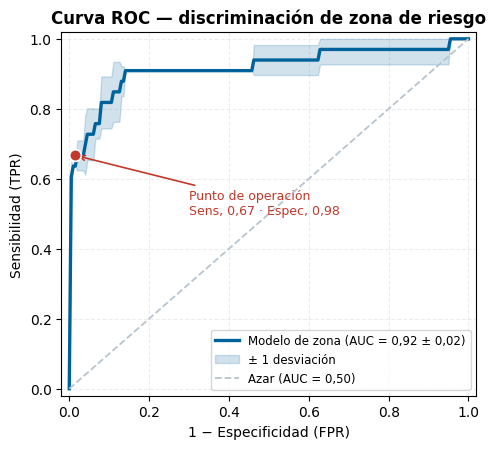

Guardado roc_zona_real.png  |  AUC = 0.9161 ± 0.0220 | Sens = 0.667 | Espec = 0.984


In [7]:
# Promediar las curvas ROC de todas las semillas sobre una malla común de FPR
fpr_grid = np.linspace(0, 1, 200)
tprs = []
for r in res:
    fpr, tpr, _ = roc_curve(r['R'], r['P'])
    tpr_i = np.interp(fpr_grid, fpr, tpr); tpr_i[0] = 0.0
    tprs.append(tpr_i)

tpr_mean = np.mean(tprs, axis=0)
tpr_std  = np.std(tprs, axis=0)
auc_mean = np.mean([r['auc'] for r in res]); auc_std = np.std([r['auc'] for r in res])
sens_mean = np.mean([r['sens'] for r in res])
espec_mean = np.mean([r['espec'] for r in res])
op_fpr = 1 - espec_mean

plt.figure(figsize=(5.0, 4.6))
plt.plot(fpr_grid, tpr_mean, color='#00629B', lw=2.4,
         label=f'Modelo de zona (AUC = {auc_mean:.2f} ± {auc_std:.2f})'.replace('.', ','))
plt.fill_between(fpr_grid, np.clip(tpr_mean-tpr_std,0,1), np.clip(tpr_mean+tpr_std,0,1),
                 alpha=0.18, color='#00629B', label='± 1 desviación')
plt.plot([0, 1], [0, 1], '--', color='#B8C4CE', lw=1.3, label='Azar (AUC = 0,50)')
plt.scatter([op_fpr], [sens_mean], color='#C0392B', s=70, zorder=5, edgecolor='white', lw=1.2)
plt.annotate(f'Punto de operación\nSens. {sens_mean:.2f} · Espec. {espec_mean:.2f}'.replace('.', ','),
             xy=(op_fpr, sens_mean), xytext=(0.30, 0.50), fontsize=9, color='#C0392B',
             arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))
plt.xlabel('1 − Especificidad (FPR)'); plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC — discriminación de zona de riesgo', fontweight='bold')
plt.xlim(-0.02, 1.02); plt.ylim(-0.02, 1.02)
plt.legend(loc='lower right', fontsize=8.5)
plt.grid(alpha=0.22, linestyle='--'); plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.savefig('roc_zona_real.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Guardado roc_zona_real.png  |  AUC = {auc_mean:.4f} ± {auc_std:.4f} | Sens = {sens_mean:.3f} | Espec = {espec_mean:.3f}")

## 8 · Qué hacer con la figura

1. Se generó **`roc_zona_real.png`** en la carpeta `notebooks/`.
2. Súbela al chat para reemplazar la Figura 6 del documento, **o** insértala tú en Word (clic derecho sobre la figura actual → *Cambiar imagen*).
3. Los modelos quedaron guardados como `tmp_zona_42.pt`, `tmp_zona_123.pt`, `tmp_zona_7.pt`. **Consérvalos** esta vez por si necesitas regenerar la curva sin reentrenar.

In [8]:
import numpy as np

# Juntar las probabilidades y etiquetas de las 3 semillas
P_all = np.concatenate([r['P'] for r in res])
R_all = np.concatenate([r['R'] for r in res])

print(f"{'Umbral':>7} | {'Sensibilidad':>12} | {'Especificidad':>13}")
print("-"*40)
for thr in [0.50, 0.45, 0.40, 0.35, 0.30]:
    yp = (P_all >= thr).astype(int)
    tp = ((yp==1)&(R_all==1)).sum(); fn = ((yp==0)&(R_all==1)).sum()
    tn = ((yp==0)&(R_all==0)).sum(); fp = ((yp==1)&(R_all==0)).sum()
    sens = tp/(tp+fn) if (tp+fn) else 0
    espec = tn/(tn+fp) if (tn+fp) else 0
    marca = "  <-- prioriza sensibilidad" if sens>=0.70 else ""
    print(f"{thr:>7.2f} | {sens:>12.3f} | {espec:>13.3f}{marca}")

 Umbral | Sensibilidad | Especificidad
----------------------------------------
   0.50 |        0.667 |         0.984
   0.45 |        0.667 |         0.983
   0.40 |        0.667 |         0.982
   0.35 |        0.697 |         0.979
   0.30 |        0.697 |         0.977


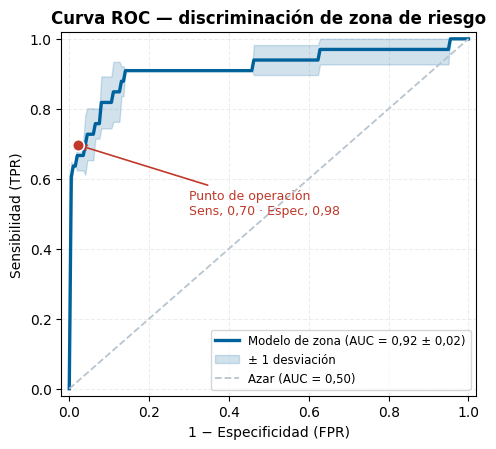

AUC = 0.9161 ± 0.0220 | Sens = 0.697 | Espec = 0.979 (umbral 0.35)


In [9]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

UMBRAL = 0.35   # punto de operación que prioriza la sensibilidad clínica

# Curva ROC promedio de las 3 semillas (no depende del umbral)
fpr_grid = np.linspace(0, 1, 200)
tprs = []
for r in res:
    fpr, tpr, _ = roc_curve(r['R'], r['P'])
    tpr_i = np.interp(fpr_grid, fpr, tpr); tpr_i[0] = 0.0
    tprs.append(tpr_i)
tpr_mean = np.mean(tprs, axis=0); tpr_std = np.std(tprs, axis=0)
auc_mean = np.mean([r['auc'] for r in res]); auc_std = np.std([r['auc'] for r in res])

# Punto de operación al umbral elegido (agregado de las 3 semillas)
P_all = np.concatenate([r['P'] for r in res]); R_all = np.concatenate([r['R'] for r in res])
yp = (P_all >= UMBRAL).astype(int)
tp=((yp==1)&(R_all==1)).sum(); fn=((yp==0)&(R_all==1)).sum()
tn=((yp==0)&(R_all==0)).sum(); fp=((yp==1)&(R_all==0)).sum()
sens = tp/(tp+fn); espec = tn/(tn+fp); op_fpr = 1 - espec

plt.figure(figsize=(5.0, 4.6))
plt.plot(fpr_grid, tpr_mean, color='#00629B', lw=2.4,
         label=f'Modelo de zona (AUC = {auc_mean:.2f} ± {auc_std:.2f})'.replace('.', ','))
plt.fill_between(fpr_grid, np.clip(tpr_mean-tpr_std,0,1), np.clip(tpr_mean+tpr_std,0,1),
                 alpha=0.18, color='#00629B', label='± 1 desviación')
plt.plot([0,1],[0,1],'--',color='#B8C4CE',lw=1.3,label='Azar (AUC = 0,50)')
plt.scatter([op_fpr],[sens],color='#C0392B',s=70,zorder=5,edgecolor='white',lw=1.2)
plt.annotate(f'Punto de operación\nSens. {sens:.2f} · Espec. {espec:.2f}'.replace('.',','),
             xy=(op_fpr,sens), xytext=(0.30,0.50), fontsize=9, color='#C0392B',
             arrowprops=dict(arrowstyle='->',color='#C0392B',lw=1.2))
plt.xlabel('1 − Especificidad (FPR)'); plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC — discriminación de zona de riesgo', fontweight='bold')
plt.xlim(-0.02,1.02); plt.ylim(-0.02,1.02)
plt.legend(loc='lower right', fontsize=8.5)
plt.grid(alpha=0.22, linestyle='--'); plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.savefig('roc_zona_real.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"AUC = {auc_mean:.4f} ± {auc_std:.4f} | Sens = {sens:.3f} | Espec = {espec:.3f} (umbral {UMBRAL})")